In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


In [2]:
# Cell 2 — Load Data
df = pd.read_excel("C:\\Users\\Jer\\Downloads\\Profit margin.xlsx")  # change to your actual filename

print(f'Shape: {df.shape}')
print(f'\nColumns:\n{df.columns.tolist()}')
print(f'\nFirst 5 rows:')
df.head()

Shape: (2107, 21)

Columns:
['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,WEST,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860001,7,0.0,14.169400
1,66,CA-2015-135545,2015-11-24,2015-11-30,Standard Class,KM-16720,Kunst Miller,Consumer,United States,Los Angeles,...,90004,WEST,FUR-FU-10000397,Furniture,Furnishings,Luxo Economy Swing Arm Lamp,79.760002,4,0.0,22.332800
2,130,US-2016-125969,2016-11-06,2016-11-10,Second Class,LS-16975,Lindsay Shagiari,Home Office,United States,Los Angeles,...,90004,WEST,FUR-FU-10003773,Furniture,Furnishings,Eldon Cleatmat Plus Chair Mats for High Pile C...,238.559998,3,0.0,26.241600
3,140,CA-2016-145583,2016-10-13,2016-10-19,Standard Class,LC-16885,Lena Creighton,Consumer,United States,Roseville,...,95661,WEST,FUR-FU-10001706,Furniture,Furnishings,Longer-Life Soft White Bulbs,43.119999,14,0.0,20.697599
4,273,CA-2015-155334,2015-07-30,2015-07-31,First Class,HA-14920,Helen Andreada,Consumer,United States,San Francisco,...,94109,WEST,FUR-FU-10003274,Furniture,Furnishings,Regeneration Desk Collection,5.280000,3,0.0,2.323200


In [3]:
print(f"Total discount in dollars: ${(df['Sales'] * df['Discount']).sum():,.2f}")

Total discount in dollars: $122,939.69


In [4]:
# Cell 3 — Feature Engineering
df_model = df.drop(columns=[
    'Row_ID', 'Order_ID', 'Customer_ID', 'Customer_Name',
    'Product_ID', 'Product_Name', 'Country', 'City', 'Postal_Code'
])

# Date features
df_model['Order_Date'] = pd.to_datetime(df_model['Order_Date'])
df_model['Ship_Date'] = pd.to_datetime(df_model['Ship_Date'])

df_model['Order_Year'] = df_model['Order_Date'].dt.year
df_model['Order_Month'] = df_model['Order_Date'].dt.month
df_model['Order_DayOfWeek'] = df_model['Order_Date'].dt.dayofweek
df_model['Quarter'] = df_model['Order_Month'].apply(lambda x: (x-1)//3 + 1)
df_model['Shipping_Days'] = (df_model['Ship_Date'] - df_model['Order_Date']).dt.days

# Sales features
df_model['Revenue_Per_Unit'] = df_model['Sales'] / df_model['Quantity']
df_model['Discount_Amount'] = df_model['Sales'] * df_model['Discount']
df_model['Sales_Per_Shipping_Day'] = df_model['Sales'] / (df_model['Shipping_Days'] + 1)
df_model['Is_Discounted'] = (df_model['Discount'] > 0).astype(int)

# Drop original date columns
df_model = df_model.drop(columns=['Order_Date', 'Ship_Date'])

print('Feature engineering done ✅')
print(f'Total features: {len(df_model.columns)}')
print(f'Columns: {df_model.columns.tolist()}')
df_model.head()

Feature engineering done ✅
Total features: 19
Columns: ['Ship_Mode', 'Segment', 'State', 'Region', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order_Year', 'Order_Month', 'Order_DayOfWeek', 'Quarter', 'Shipping_Days', 'Revenue_Per_Unit', 'Discount_Amount', 'Sales_Per_Shipping_Day', 'Is_Discounted']


,Ship_Mode,Segment,State,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_DayOfWeek,Quarter,Shipping_Days,Revenue_Per_Unit,Discount_Amount,Sales_Per_Shipping_Day,Is_Discounted
0,Standard Class,Consumer,California,WEST,Furniture,Furnishings,48.860001,7,0.0,14.169400,2014,6,0,2,5,6.980000,0.0,8.143333,0
1,Standard Class,Consumer,California,WEST,Furniture,Furnishings,79.760002,4,0.0,22.332800,2015,11,1,4,6,19.940001,0.0,11.394286,0
2,Second Class,Home Office,California,WEST,Furniture,Furnishings,238.559998,3,0.0,26.241600,2016,11,6,4,4,79.519999,0.0,47.712000,0
3,Standard Class,Consumer,California,WEST,Furniture,Furnishings,43.119999,14,0.0,20.697599,2016,10,3,4,6,3.080000,0.0,6.160000,0
4,First Class,Consumer,California,WEST,Furniture,Furnishings,5.280000,3,0.0,2.323200,2015,7,3,3,1,1.760000,0.0,2.640000,0


In [5]:
# Cell 4 — Encoding
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Ship_Mode', 'Segment', 'State', 'Region', 'Category', 'Sub_Category']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('Encoding done ✅')
print(f'Shape: {df_model.shape}')
df_model.head()

Encoding done ✅
Shape: (2107, 19)


,Ship_Mode,Segment,State,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_DayOfWeek,Quarter,Shipping_Days,Revenue_Per_Unit,Discount_Amount,Sales_Per_Shipping_Day,Is_Discounted
0,3,0,3,3,0,2,48.860001,7,0.0,14.169400,2014,6,0,2,5,6.980000,0.0,8.143333,0
1,3,0,3,3,0,2,79.760002,4,0.0,22.332800,2015,11,1,4,6,19.940001,0.0,11.394286,0
2,2,2,3,3,0,2,238.559998,3,0.0,26.241600,2016,11,6,4,4,79.519999,0.0,47.712000,0
3,3,0,3,3,0,2,43.119999,14,0.0,20.697599,2016,10,3,4,6,3.080000,0.0,6.160000,0
4,0,0,3,3,0,2,5.280000,3,0.0,2.323200,2015,7,3,3,1,1.760000,0.0,2.640000,0


In [6]:
# Cell 5 — Define Features and Target
X = df_model.drop(columns=['Profit'])
y = df_model['Profit']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeatures: {X.columns.tolist()}')

Features shape: (2107, 18)
Target shape: (2107,)

Features: ['Ship_Mode', 'Segment', 'State', 'Region', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Order_Year', 'Order_Month', 'Order_DayOfWeek', 'Quarter', 'Shipping_Days', 'Revenue_Per_Unit', 'Discount_Amount', 'Sales_Per_Shipping_Day', 'Is_Discounted']


In [7]:
# Cell 6 — Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% training, 20% testing
    random_state=42     # reproducibility
)

print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (1685, 18)
Testing set: (422, 18)


In [8]:
# Cell 7 — Build XGBoost Model
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,        # number of trees
    learning_rate=0.1,       # how fast the model learns
    max_depth=5,             # how deep each tree grows
    subsample=0.8,           # random sample of rows per tree
    colsample_bytree=0.8,    # random sample of columns per tree
    random_state=42
)

model.fit(X_train, y_train)
print('Model trained successfully ✅')

Model trained successfully ✅


In [9]:
# Cell 8 — Evaluate
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print(f'MAE:  ${mae:.2f}')
print(f'RMSE: ${rmse:.2f}')
print(f'R²:   {r2:.4f}')

MAE:  $31.25
RMSE: $80.51
R²:   0.7206


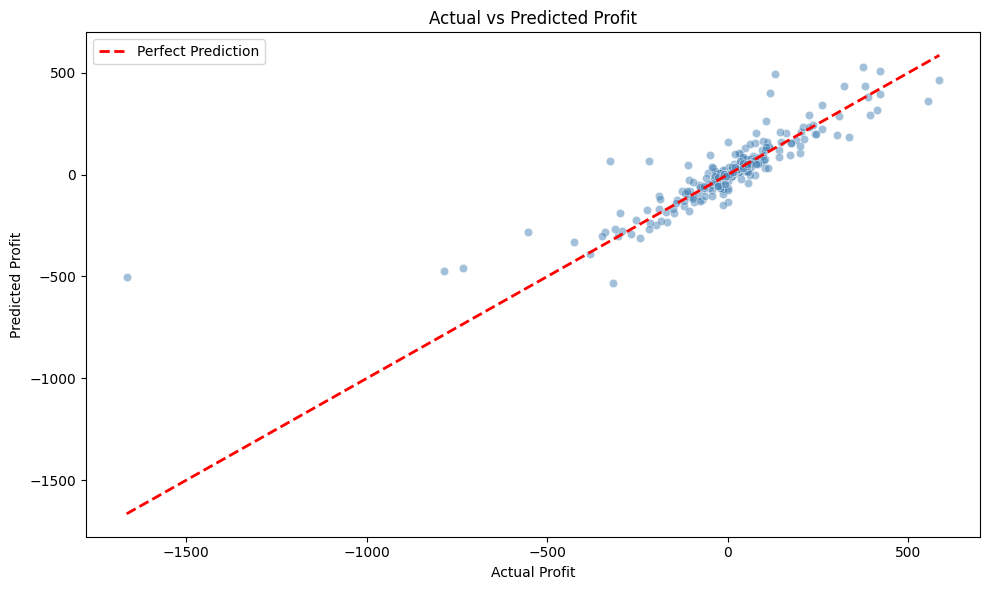

In [10]:
# Cell 9 — Actual vs Predicted Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit')
plt.legend()
plt.tight_layout()
plt.show()

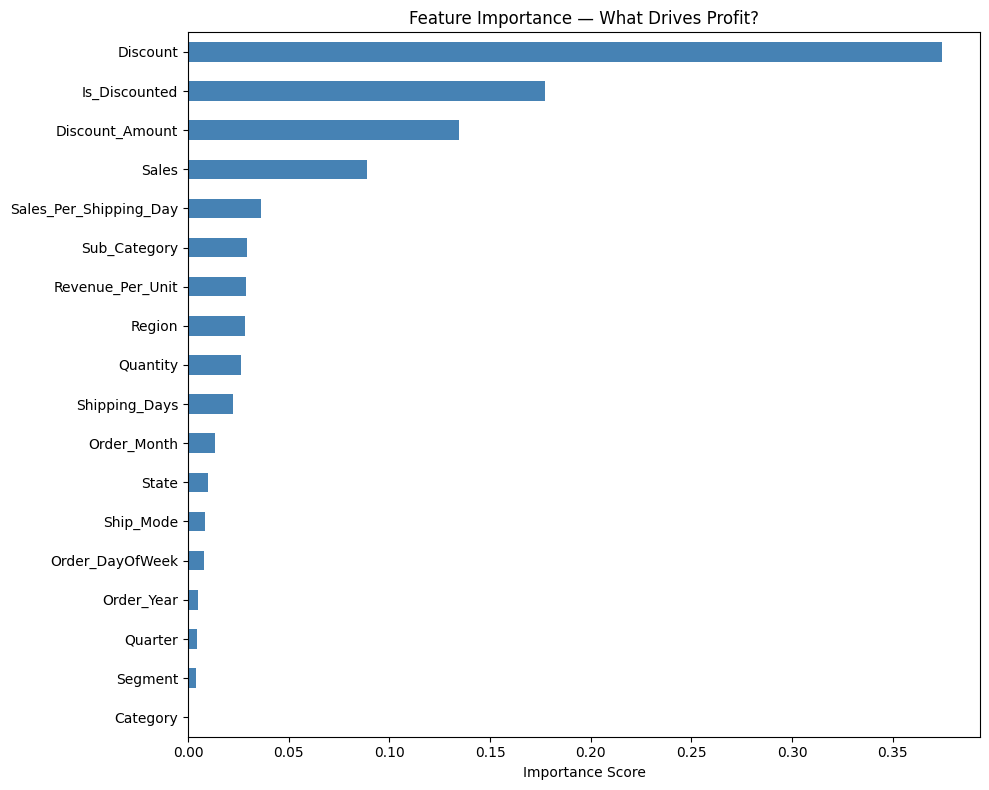

In [11]:
# Cell 10 — Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — What Drives Profit?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [12]:
# Cell 11 — Remove Low Importance Features
low_importance = ['Category', 'Segment', 'Quarter', 'Order_Year', 
                  'Order_DayOfWeek', 'Ship_Mode', 'State']

X_reduced = X.drop(columns=low_importance)

# Redo train/test split with reduced features
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_reduced, y, 
    test_size=0.2, 
    random_state=42
)

print(f'Reduced features: {X_reduced.columns.tolist()}')
print(f'Training set: {X_train2.shape}')
print(f'Testing set: {X_test2.shape}')

Reduced features: ['Region', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Order_Month', 'Shipping_Days', 'Revenue_Per_Unit', 'Discount_Amount', 'Sales_Per_Shipping_Day', 'Is_Discounted']
Training set: (1685, 11)
Testing set: (422, 11)


In [13]:
# Cell 12 — Retrain with Reduced Features
model2 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)
rmse2 = np.sqrt(np.mean((y_test2 - y_pred2)**2))

print(f'--- Reduced Model ---')
print(f'MAE:  ${mae2:.2f}')
print(f'RMSE: ${rmse2:.2f}')
print(f'R²:   {r2_2:.4f}')

print(f'\n--- Original Model ---')
print(f'MAE:  ${mae:.2f}')
print(f'RMSE: ${rmse:.2f}')
print(f'R²:   {r2:.4f}')

--- Reduced Model ---
MAE:  $28.60
RMSE: $70.96
R²:   0.7829

--- Original Model ---
MAE:  $31.25
RMSE: $80.51
R²:   0.7206


In [16]:
# Cell 13 — Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train2, y_train2)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best R² from cross validation: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best R² from cross validation: 0.8219


In [17]:
# Cell 14 — Final Model with Best Parameters
best_model = XGBRegressor(
    colsample_bytree=0.9,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=200,
    subsample=0.8,
    random_state=42
)

best_model.fit(X_train2, y_train2)
y_pred_best = best_model.predict(X_test2)

mae_best = mean_absolute_error(y_test2, y_pred_best)
r2_best = r2_score(y_test2, y_pred_best)
rmse_best = np.sqrt(np.mean((y_test2 - y_pred_best)**2))

print(f'--- Final Tuned Model ---')
print(f'MAE:  ${mae_best:.2f}')
print(f'RMSE: ${rmse_best:.2f}')
print(f'R²:   {r2_best:.4f}')

print(f'\n--- Reduced Model ---')
print(f'MAE:  ${mae2:.2f}')
print(f'RMSE: ${rmse2:.2f}')
print(f'R²:   {r2_2:.4f}')

print(f'\n--- Original Model ---')
print(f'MAE:  ${mae:.2f}')
print(f'RMSE: ${rmse:.2f}')
print(f'R²:   {r2:.4f}')

--- Final Tuned Model ---
MAE:  $29.27
RMSE: $76.81
R²:   0.7457

--- Reduced Model ---
MAE:  $28.60
RMSE: $70.96
R²:   0.7829

--- Original Model ---
MAE:  $31.25
RMSE: $80.51
R²:   0.7206


In [18]:
# Cell 15 — Adjust Tuned Model to Reduce Overfitting
best_model2 = XGBRegressor(
    colsample_bytree=0.9,
    learning_rate=0.05,
    max_depth=4,        # reduced from 6 to prevent overfitting
    n_estimators=300,   # more trees with slower learning
    subsample=0.8,
    reg_alpha=0.1,      # L1 regularization
    reg_lambda=1.5,     # L2 regularization
    random_state=42
)

best_model2.fit(X_train2, y_train2)
y_pred_best2 = best_model2.predict(X_test2)

mae_best2 = mean_absolute_error(y_test2, y_pred_best2)
r2_best2 = r2_score(y_test2, y_pred_best2)
rmse_best2 = np.sqrt(np.mean((y_test2 - y_pred_best2)**2))

print(f'--- Regularized Model ---')
print(f'MAE:  ${mae_best2:.2f}')
print(f'RMSE: ${rmse_best2:.2f}')
print(f'R²:   {r2_best2:.4f}')

print(f'\n--- Reduced Model (Current Best) ---')
print(f'MAE:  ${mae2:.2f}')
print(f'RMSE: ${rmse2:.2f}')
print(f'R²:   {r2_2:.4f}')

--- Regularized Model ---
MAE:  $28.94
RMSE: $72.27
R²:   0.7748

--- Reduced Model (Current Best) ---
MAE:  $28.60
RMSE: $70.96
R²:   0.7829


In [19]:
# Cell 16 — Save the Final Model
import joblib

joblib.dump(model2, 'profit_prediction_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print('Model saved successfully ✅')
print('Label encoder saved successfully ✅')

Model saved successfully ✅
Label encoder saved successfully ✅
